# EDA

## Imports

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations
import os

/home/guima/anaconda3/envs/ml/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
class DiabeticDataLoader:
    def __init__(self, df_raw):
        self.df_raw = df_raw.copy()
        self.df_clean = None
        self.df_no_outliers = None
        self.scaler = None

    def clean_data(self):
        df = self.df_raw.copy()
        
        # Remover colunas constantes
        constant_cols = ['examide', 'citoglipton']
        df.drop(columns=constant_cols, inplace=True, errors='ignore')
        
        # Substituir '?' por NaN de todas as colunas
        df.replace('?', np.nan, inplace=True)
        
        # Lidar com max_glu_serum e A1Cresult
        for col in ['max_glu_serum', 'A1Cresult']:
            df[col] = df[col].replace('None', np.nan)
            df[col + '_measured'] = (~df[col].isna()).astype(int)
            
        # Indicador de peso registrado e conversão
        df['weight_recorded'] = (~df['weight'].isna()).astype(int)
        df['weight'] = df['weight'].astype('category')
        
        # Colunas categóricas
        categorical_cols = [
            'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id',
            'admission_source_id', 'payer_code', 'medical_specialty',
            'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult',
            'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
            'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
            'insulin', 'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone',
            'change', 'diabetesMed', 'readmitted'
        ]
        
        for col in categorical_cols:
            if col in df.columns:
                df[col] = df[col].astype('category')
        
        self.df_clean = df
        return df

    def remove_outliers(self):
        if self.df_clean is None:
            raise ValueError("Data must be cleaned before outlier removal.")
        
        df = self.df_clean.copy()

        outlier_cols = [
            'time_in_hospital', 'num_lab_procedures', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient'
        ]
        
        self.thresholds = {}
        for col in outlier_cols:
            if col in df.columns:
                # Calcula Min e P99 para ser o thresholds
                low = df[col].min()
                high = df[col].quantile(0.99)
                self.thresholds[col] = (low, high)
        
        mask = pd.Series(True, index=df.index)
        for feature, (low, high) in self.thresholds.items():
            if feature in df.columns:
                mask &= df[feature].between(low, high)
                
        df_no_outliers = df.loc[mask].copy()
        self.df_no_outliers = df_no_outliers
        return df_no_outliers
    
    def get_clean_data(self):
        if self.df_clean is None:
            self.clean_data()
        return self.df_clean
    
    def get_no_outliers_data(self):
        if self.df_no_outliers is None:
            self.remove_outliers()
        return self.df_no_outliers

    def get_features_target(self):
        df = self.get_no_outliers_data()
        exclude_cols = ['encounter_id', 'patient_nbr', 'readmitted']
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        X = df[feature_cols]
        y = df['readmitted']
        return X, y

    def get_train_test_split(self, test_size=0.2, random_state=42):
        # Limpa os dados de forma global
        df_clean = self.clean_data()
        
        # Separa X e Y
        X, y = self.get_features_target(df_clean)
        
        # Faz o split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=random_state
        )
        
        # Remove outliers no train
        train_combined = pd.concat([X_train, y_train], axis=1)
        train_combined = self.remove_outliers(train_combined, calculate_thresholds=True)
        X_train = train_combined.drop(columns=['readmitted'])
        y_train = train_combined['readmitted']
        
        # Padronização
        numeric_cols = [
            'time_in_hospital', 'num_lab_procedures', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient',
            'num_procedures', 'number_diagnoses'
        ]
        
        self.scaler = StandardScaler()
        # FIT apenas no treino
        X_train[numeric_cols] = self.scaler.fit_transform(X_train[numeric_cols])
        # TRANSFORM no teste
        X_test[numeric_cols] = self.scaler.transform(X_test[numeric_cols])
        
        return X_train, X_test, y_train, y_test
    
    def save_processed_data(self, directory=os.path.join('..','data', 'processed')):
        if self.df_no_outliers is None:
            raise ValueError("No processed data to save. Please run the processing steps first.")
        
        os.makedirs(directory, exist_ok=True)
        self.df_no_outliers.to_csv(os.path.join(directory, 'diabetic_data_processed.csv'), index=False)

In [3]:
df_diabetic_data = pd.read_csv(os.path.join('..','data', 'raw','diabetic_data.csv'))
df_diabetic_loader = DiabeticDataLoader(df_diabetic_data)
df_diabetic_clean = df_diabetic_loader.get_clean_data()
df_diabetic_no_outliers = df_diabetic_loader.get_no_outliers_data()
df_diabetic_features, df_diabetic_target = df_diabetic_loader.get_features_target()
#df_X_train, df_X_test, df_y_train, df_y_test = df_diabetic_loader.get_train_test_split()

## Quality Assessment

In [4]:
df = pd.read_csv(os.path.join('..','data', 'raw','diabetic_data.csv'))
print(f'{df.shape[0]} rows and {df.shape[1]} columns')
df.head()

101766 rows and 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
len(df['patient_nbr'].unique()) #são 71518 pacientes, cerca 30000 saídas do hospital são de pacientes que foram readmitidos

71518

In [6]:
df.select_dtypes(include='number').info() #somente variaveis numericas

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   admission_type_id         101766 non-null  int64
 3   discharge_disposition_id  101766 non-null  int64
 4   admission_source_id       101766 non-null  int64
 5   time_in_hospital          101766 non-null  int64
 6   num_lab_procedures        101766 non-null  int64
 7   num_procedures            101766 non-null  int64
 8   num_medications           101766 non-null  int64
 9   number_outpatient         101766 non-null  int64
 10  number_emergency          101766 non-null  int64
 11  number_inpatient          101766 non-null  int64
 12  number_diagnoses          101766 non-null  int64
dtypes: int64(13)
memory usage: 10.1 MB


In [7]:
df.select_dtypes(include='object').columns #variaveis categoricas

/tmp/ipykernel_29574/1015326711.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns #variaveis categoricas


Index(['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty',
       'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='str')

In [8]:
null_counts = df.isnull().sum() # contagem de valores nulos por coluna, observamos que os valores nulos são muito altos, logo podemos retirar as colunas com muitos valores nulos
df_null_counts = null_counts[null_counts > 0]
df_null_counts

max_glu_serum    96420
A1Cresult        84748
dtype: int64

In [9]:
#df = df.drop(columns=df_null_counts.index) #nao se remove valores nulos, pois eles podem ser importantes para o modeloo e dizem que determinada característica não foi medida anteriormente
#df

In [10]:
df[df.duplicated()] #não há duplicações no dataset

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted


## Numeric Analyses

In [ ]:
numerical_columns = df_diabetic_no_outliers.select_dtypes(include='number').columns #descrição estatística das variáveis numéricas
numerical_df = df_diabetic_no_outliers[numerical_columns].drop(columns=['patient_nbr','encounter_id'], errors='ignore') #removendo a coluna de id, pois não é relevante para a análise
numerical_df.describe()

In [ ]:

for col in numerical_df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df_diabetic_no_outliers, x=col, kde=True, hue='readmitted') 
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
pd.plotting.scatter_matrix(df_diabetic_no_outliers[numerical_df.columns], figsize=(12, 12), diagonal='kde', alpha=0.5, marker='o')
plt.suptitle('Matriz de Dispersão (Pandas)', y=1.02, fontsize=16)
plt.show()

In [ ]:
matrix_corr = numerical_df.corr(method='spearman') #matriz de correlação entre as variáveis numéricas utilizando o método de Spearman, que é mais adequado para não linearidades e dados com outliers
g = sns.clustermap( #mapa com uso de clusterização hierárquica para organizar as variáveis de acordo com suas correlações, facilitando a visualização de padrões
    matrix_corr,
    figsize=(7,7),     
    cmap='Spectral',           
    center=0,              
    annot=False,           
    fmt='.2f',            
    linewidths=.75,      
    cbar_kws={"shrink": .5} 
)

## Categorical Analyses

In [11]:
categorical_columns = df_diabetic_no_outliers.select_dtypes(include='category').columns #descrição estatística das variáveis categóricas
categorical_df = df_diabetic_no_outliers[categorical_columns]
categorical_df.describe()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,payer_code,medical_specialty,diag_1,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,95378,97601,97601,2968,97601,97601,97601,58719,49799,97580,...,97601,97601,97601,97601,97601,97601,97601,97601,97601,97601
unique,5,3,10,9,8,26,17,17,72,715,...,3,4,4,2,2,2,2,2,2,3
top,Caucasian,Female,[70-80),[75-100),1,1,7,MC,InternalMedicine,428,...,No,No,No,No,No,No,No,No,Yes,NO
freq,72972,52539,25190,1250,51856,58067,55004,31130,14132,6583,...,97562,46115,96917,97588,97600,97600,97600,53100,74863,53210


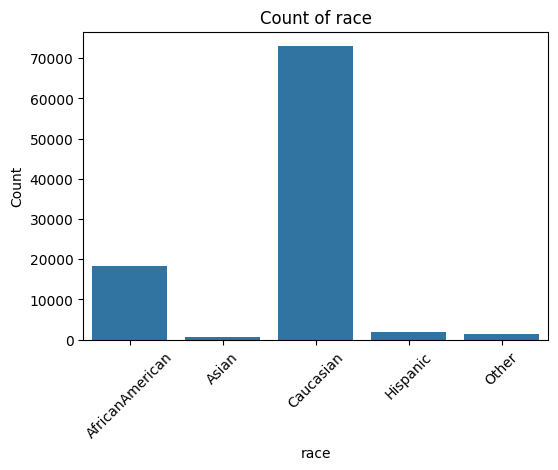

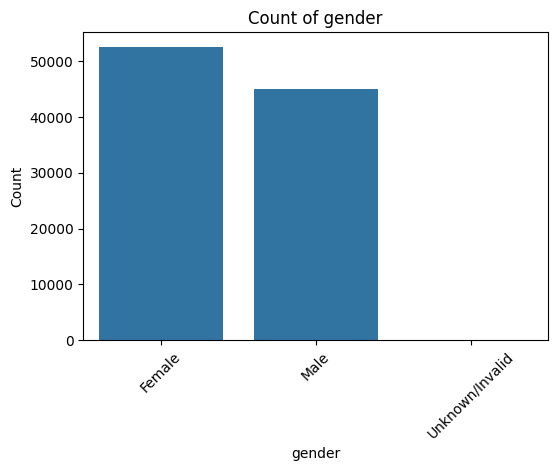

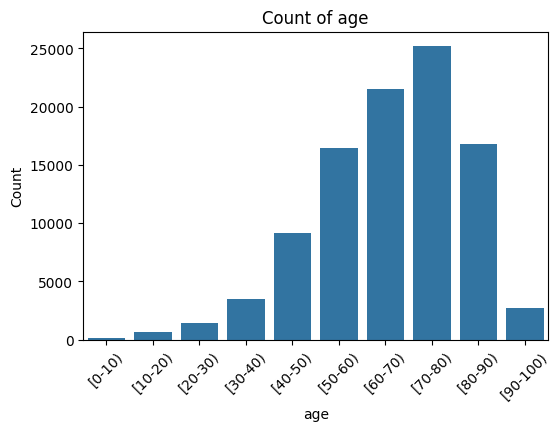

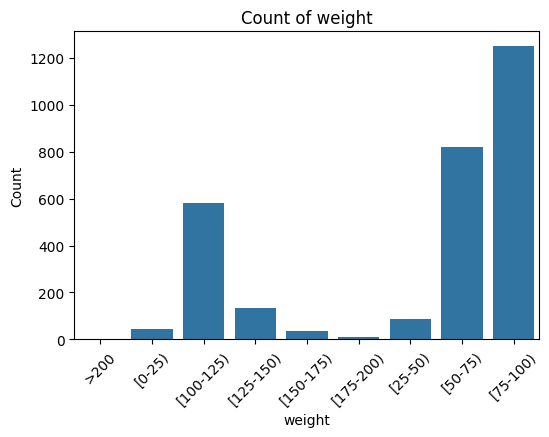

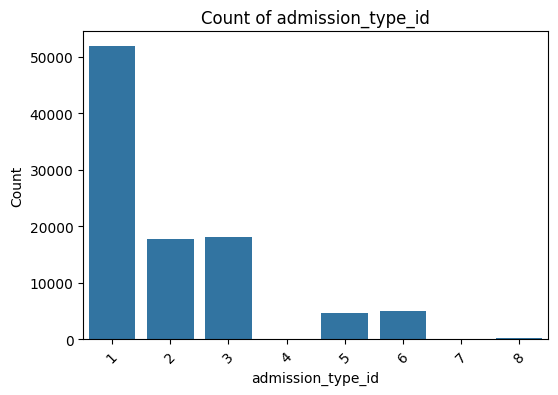

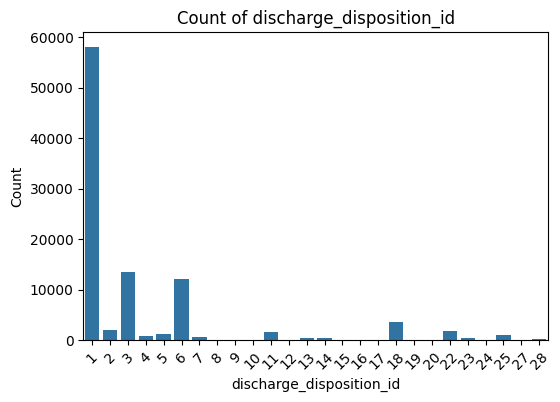

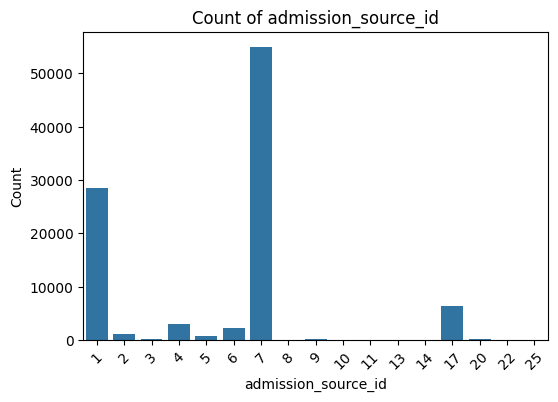

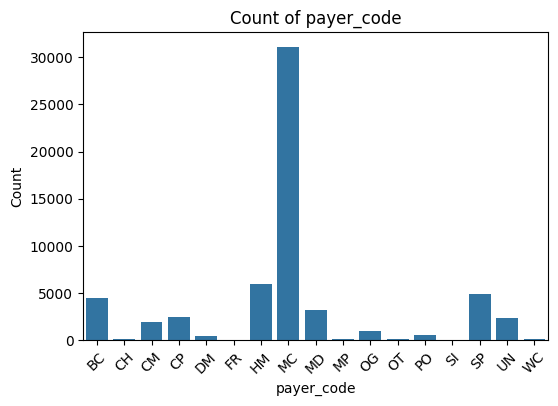

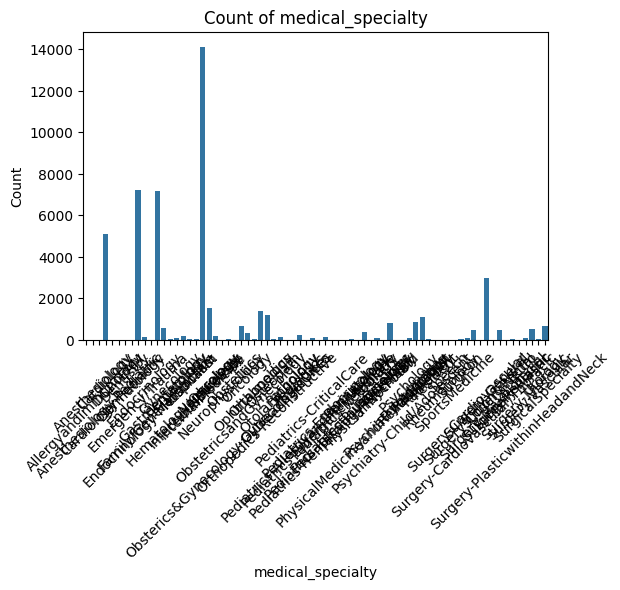

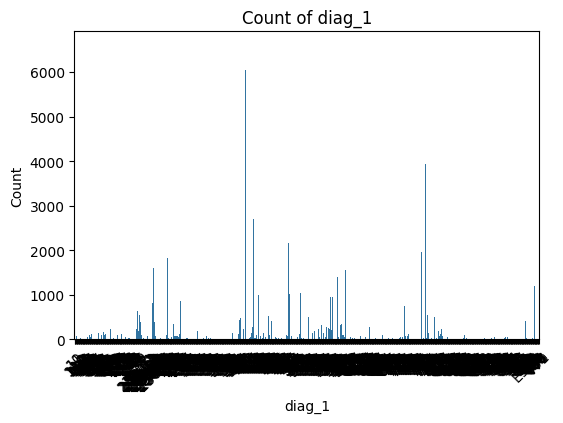

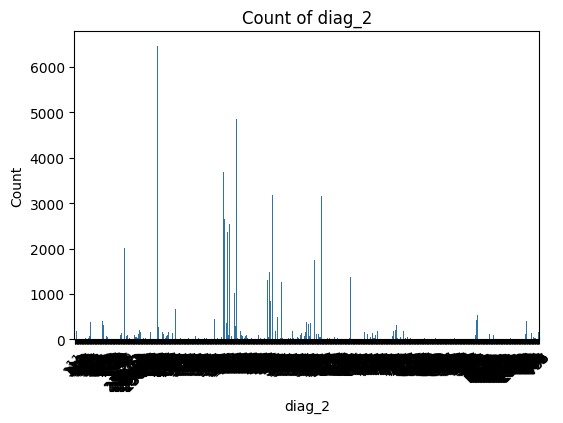

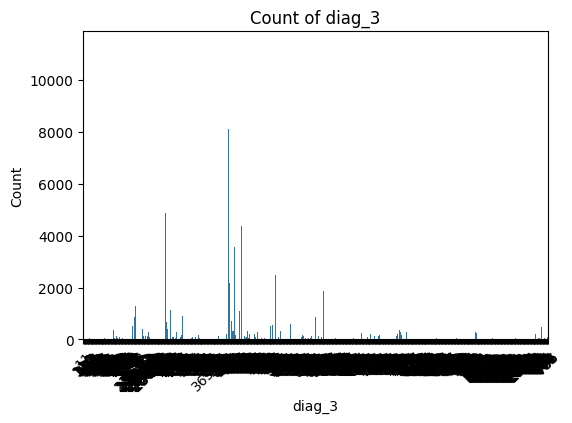

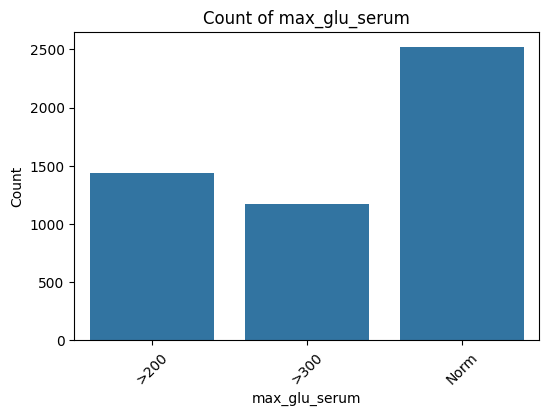

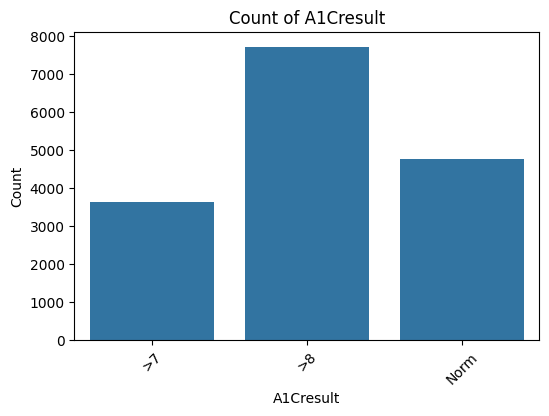

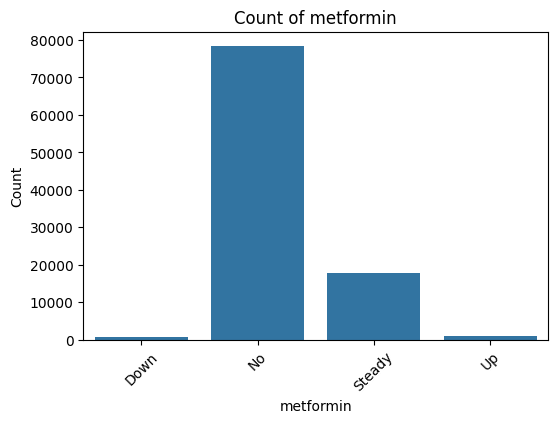

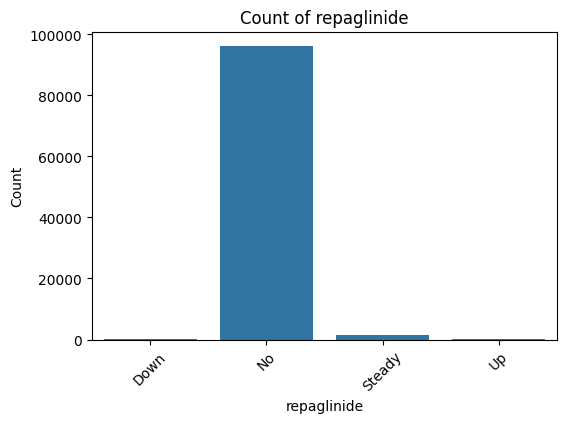

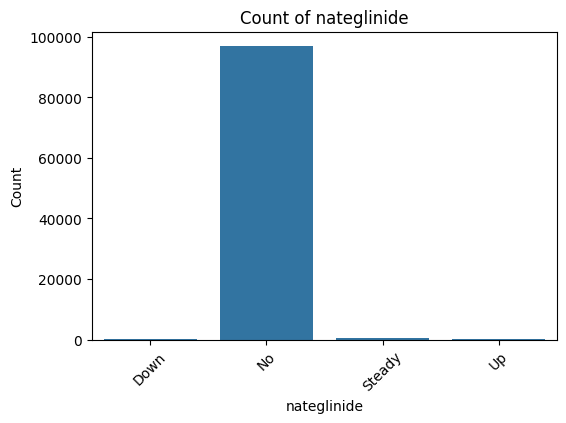

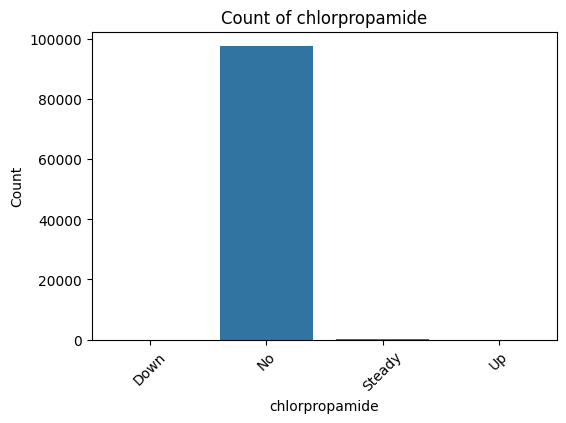

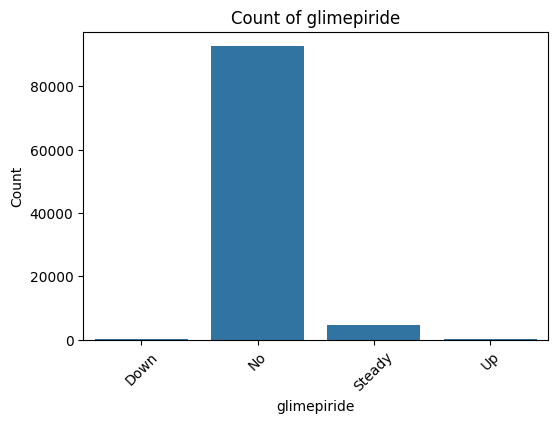

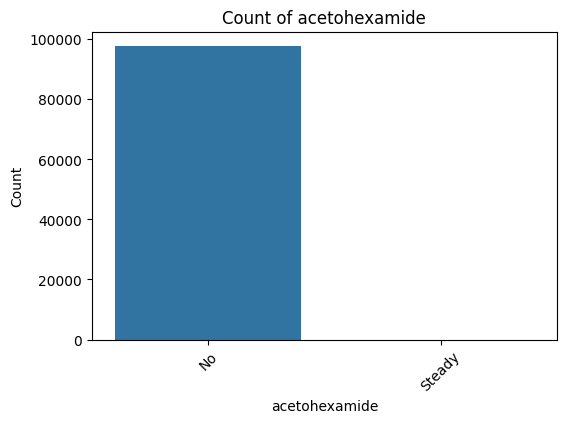

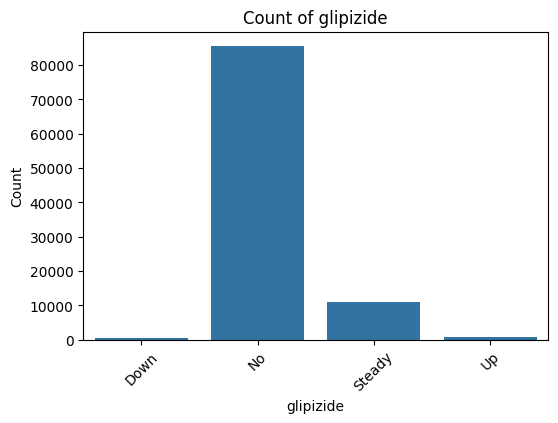

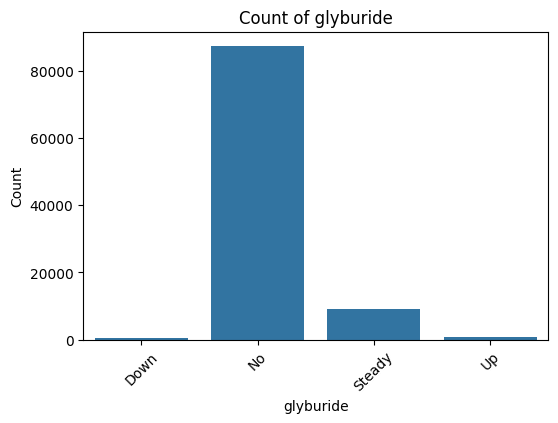

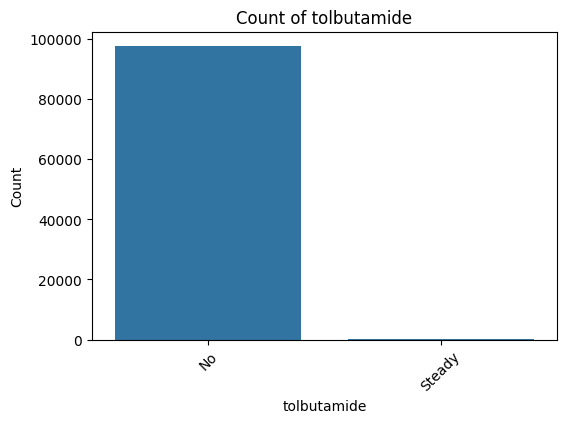

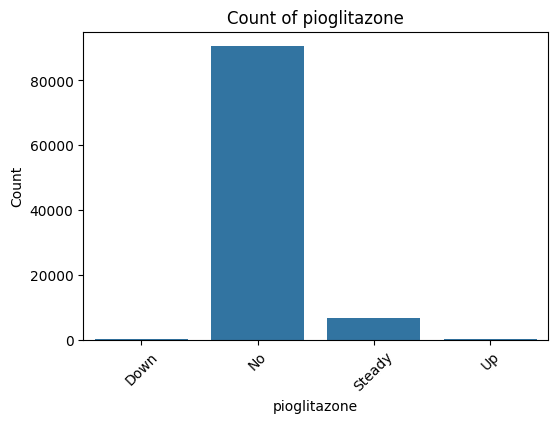

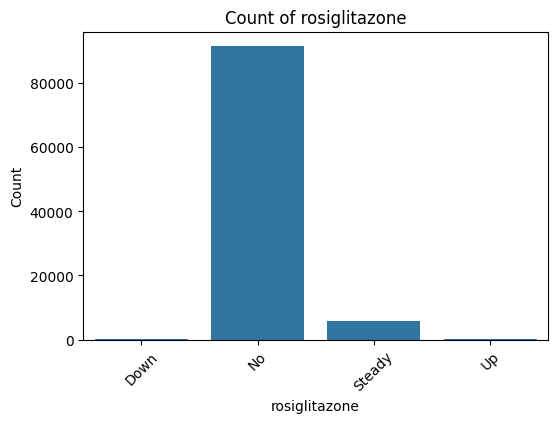

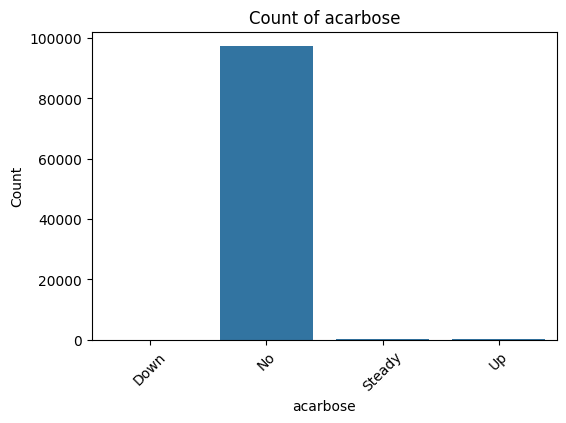

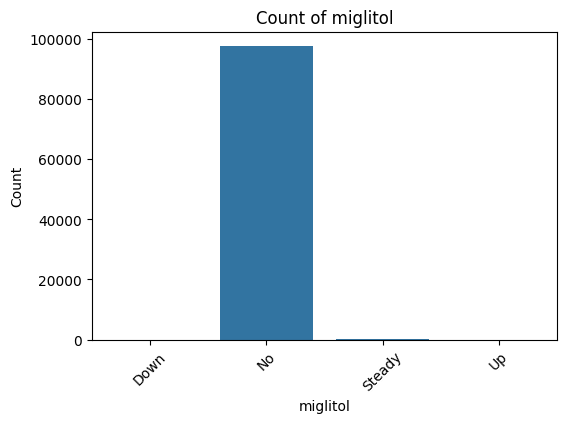

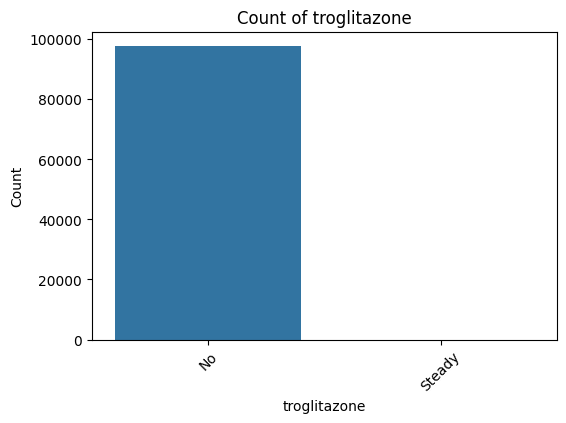

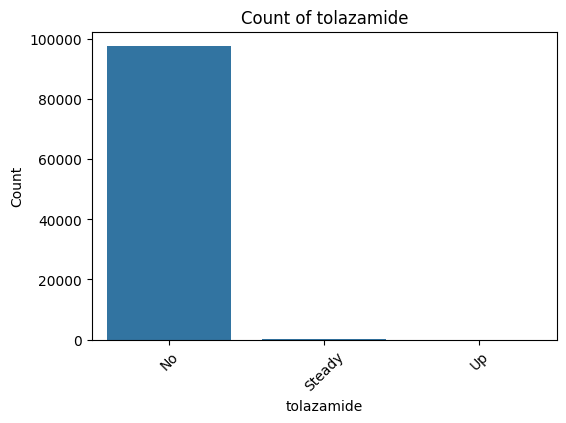

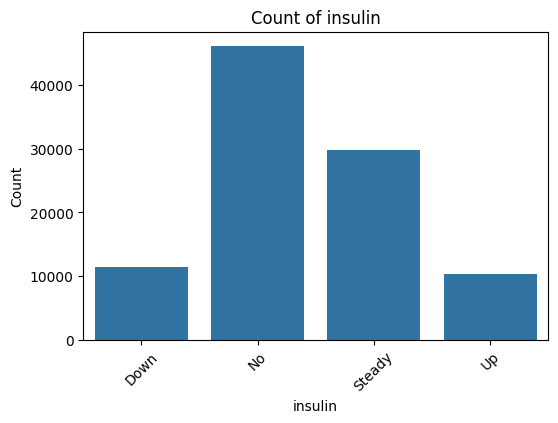

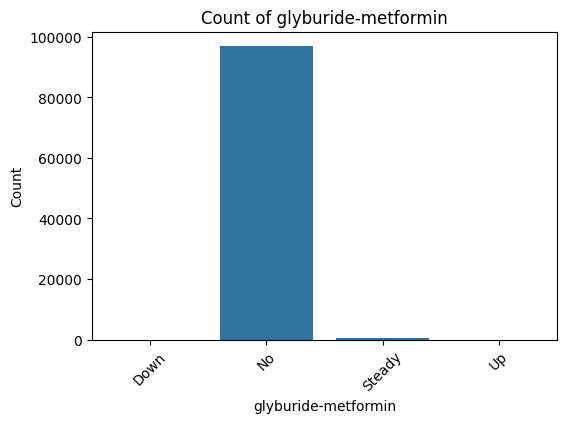

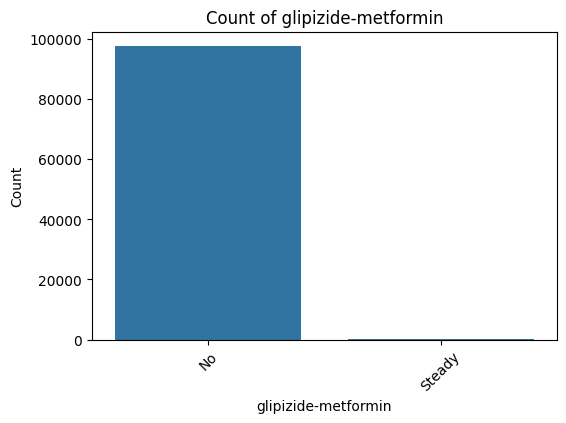

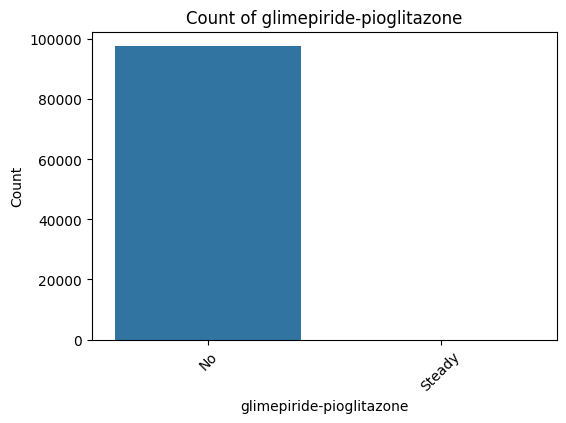

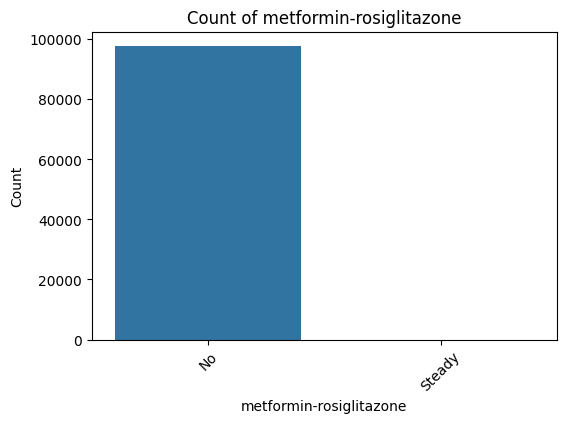

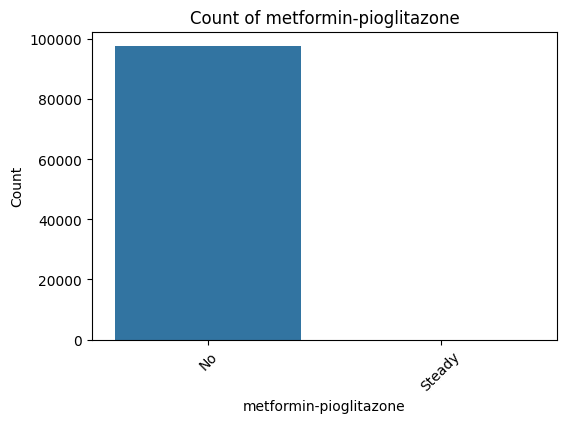

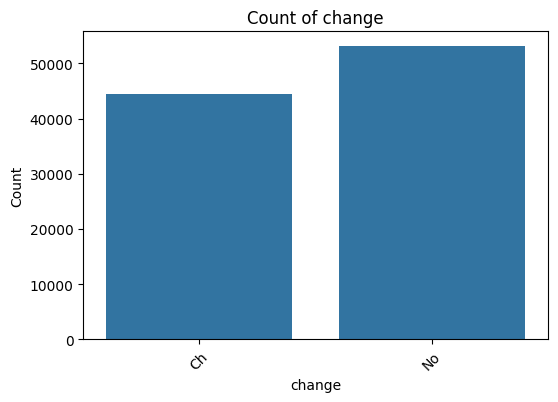

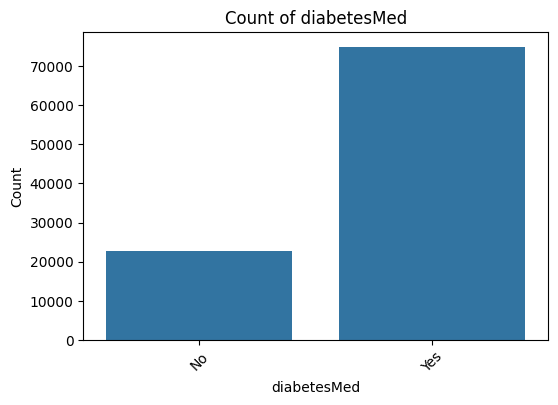

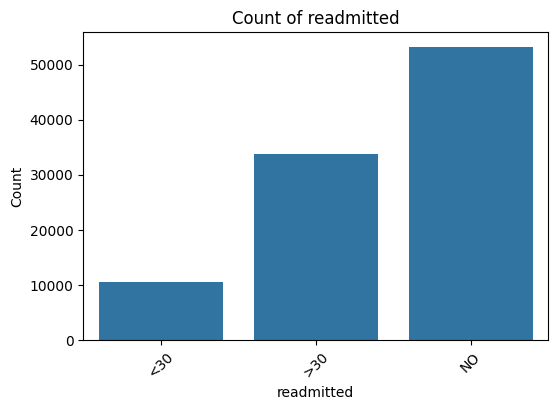

In [12]:
categorical_columns = categorical_df.columns
for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=categorical_df, x=col) #gráfico de barras para visualizar a distribuição das categorias em cada coluna categórica
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45) #rotaciona os rótulos do eixo x para melhor visualização
    plt.show()
    
#valores muito ruidosos, muitas categorias com poucos registros, dificultam a análise, retiramos eles, assim como aqueles que possuem um único registro

In [ ]:
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

n_low = 4
n_high = 8

for col1, col2 in itertools.combinations(categorical_df.columns, 2):
    
    nu1 = categorical_df[col1].nunique()
    nu2 = categorical_df[col2].nunique()
    
    is_target = (col1 == 'readmitted' or col2 == 'readmitted')
    
    condicao_padrao = (n_low < nu1 < n_high) and (n_low < nu2 < n_high)
    
    if is_target:
        outro_nu = nu2 if col1 == 'readmitted' else nu1
        deve_plotar = (n_low < outro_nu < n_high)
    else:
        deve_plotar = condicao_padrao
        
    if deve_plotar:
        try:
            plt.figure(figsize=(6,4))
            sns.countplot(data=categorical_df, x=col1, hue=col2)
            plt.title(f'Count of {col1} by {col2}')
            plt.xlabel(col1)
            plt.ylabel('Count')
            plt.xticks(rotation=45)
            plt.legend(title=col2)
            plt.tight_layout()
            plt.show()
        except ValueError:
            print(f"Cannot plot {col1} vs {col2} due to too many categories.")

## Bivariate Analysis (Categorical and Numerical)

In [ ]:
df = numerical_df.join(categorical_df)
df

In [ ]:
def pairwise_proportion_test(dataframe, cat_col, target_col='readmitted', success_class='<30'):
    resultados = []
    
    categorias = dataframe[cat_col].dropna().unique()
    
    if len(categorias) > 15:
        return pd.DataFrame([{"Erro": f"Muitas categorias em {cat_col} para teste pareado."}])

    pares = list(combinations(categorias, 2))
    
    num_comparacoes = len(pares)
    alpha_ajustado = 0.05 / num_comparacoes if num_comparacoes > 0 else 0.05
    
    for cat1, cat2 in pares:
        grupo1 = dataframe[dataframe[cat_col] == cat1][target_col]
        grupo2 = dataframe[dataframe[cat_col] == cat2][target_col]
        
        sucessos = np.array([(grupo1 == success_class).sum(), (grupo2 == success_class).sum()])
        total = np.array([len(grupo1), len(grupo2)])
        
        if total[0] == 0 or total[1] == 0:
            continue
            
        stat, p_val = proportions_ztest(count=sucessos, nobs=total)
        
        prop1 = sucessos[0] / total[0]
        prop2 = sucessos[1] / total[1]
        
        resultados.append({
            'Variável': cat_col,
            'Comparação': f'{cat1} vs {cat2}',
            f'Prop. {cat1}': prop1,
            f'Prop. {cat2}': prop2,
            'Diferença Absoluta': abs(prop1 - prop2),
            'P-Valor': p_val,
            f'Significativo (Bonferroni α={alpha_ajustado:.4f})': p_val < alpha_ajustado 
        })
        
    return pd.DataFrame(resultados).sort_values(by='P-Valor')

for col in categorical_df.columns:
    if col != 'readmitted': 
        df_teste_z = pairwise_proportion_test(df, col, target_col='readmitted', success_class='<30')
        display(df_teste_z)

In [ ]:
resultados_cat = []

for col in categorical_df.columns:
    if col != 'readmitted':
        tabela = pd.crosstab(categorical_df[col], categorical_df['readmitted'])
        chi2, p_val, dof, expected = chi2_contingency(tabela)
        
        resultados_cat.append({
            'Variável': col,
            'P-Valor': p_val,
            'Significativo (α=0.05)': p_val < 0.05
        })

display(pd.DataFrame(resultados_cat).sort_values(by='P-Valor'))

In [ ]:
for col in categorical_df.columns:
    if col != 'readmitted':
        # Cria uma tabela cruzada com proporções nas linhas (normalize='index')
        crosstab = pd.crosstab(categorical_df[col], categorical_df['readmitted'], normalize='index')
        
        # Plota o gráfico de barras empilhadas
        crosstab.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='viridis')
        
        plt.title(f'Proporção de Readmissão por {col}')
        plt.ylabel('Proporção (0 a 1)')
        plt.xlabel(col)
        plt.legend(title='Readmitted', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [ ]:
def permutation_test_corrected(group1, group2, n_permutations=1000):
    obs_diff = np.abs(np.mean(group1) - np.mean(group2))
    combined = np.concatenate([group1, group2])
    n_group1 = len(group1)
    
    extreme_count = 0
    
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        pseudo_group1 = combined[:n_group1]
        pseudo_group2 = combined[n_group1:]
        pseudo_diff = np.abs(np.mean(pseudo_group1) - np.mean(pseudo_group2))
        
        if pseudo_diff >= obs_diff:
            extreme_count += 1
            
    p_value = (extreme_count + 1) / (n_permutations + 1)
    
    return obs_diff, p_value

target_group_full = df[df['readmitted'] == '<30']
control_group_full = df[df['readmitted'] != '<30']

results = []
sample_size = 2000 

for col in numerical_df.columns:
    target_vals = target_group_full[col]
    control_vals = control_group_full[col]
    
    if len(target_vals) >= sample_size and len(control_vals) >= sample_size:
        target_sample = np.random.choice(target_vals, size=sample_size, replace=False)
        control_sample = np.random.choice(control_vals, size=sample_size, replace=False)
        
        obs_diff, p_val = permutation_test_corrected(target_sample, control_sample, n_permutations=1000)
        
        results.append({
            'Variable': col,
            'Mean <30 (Sample)': np.mean(target_sample),
            'Mean Others (Sample)': np.mean(control_sample),
            'Difference (Abs)': obs_diff,
            'P-Value': p_val,
            'Significant (α=0.05)': p_val < 0.05
        })

results_df = pd.DataFrame(results)
display(results_df)